In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110})

def etiquetar_barras(ax):
    for cont in ax.containers:
        ax.bar_label(cont, fontsize=9, padding=2)

In [9]:
raw = pd.read_csv('Analisis_GAC_Full7agosto_2026_Leads_por_Canal.csv', header=None)
canales = raw.iloc[4:10, [0] + list(range(1, 31))].copy()
canales.columns = ['Canal'] + list(pd.date_range('2024-01-01', periods=30, freq='MS').strftime('%Y-%m'))
canales['Canal'] = canales['Canal'].str.strip()

# --- Tratamiento de valores nulos ---
canales = canales.replace({'-': np.nan})              # guiones = sin dato
for c in canales.columns[1:]:
    canales[c] = pd.to_numeric(canales[c], errors='coerce')
print("Nulos antes de limpiar:", canales.isnull().sum().sum())
canales[canales.columns[1:]] = canales[canales.columns[1:]].fillna(0)  # sin leads ese mes = 0
print("Nulos después de limpiar:", canales.isnull().sum().sum())

leads_canal = canales.melt(id_vars='Canal', var_name='Periodo', value_name='Leads')
leads_canal.to_csv('leads_por_canal_clean.csv', index=False)

Nulos antes de limpiar: 0
Nulos después de limpiar: 0


In [10]:
raw_sdc = pd.read_csv('Analisis_GAC_Full7agosto_2026_SDC.csv', header=None)

# Filas 5-9 = Generadas, Aprobadas, Condicionadas, Rechazadas, Formalizadas
# Columnas 1-31 = Enero 2024 a Julio 2026 (31 meses)
periodo = pd.date_range('2024-01-01', periods=31, freq='MS').strftime('%b-%y')
filas = {'Generadas': 5, 'Aprobadas': 6, 'Condicionadas': 7, 'Rechazadas': 8, 'Formalizadas': 9}

sdc = pd.DataFrame({'Periodo': periodo})
for nombre, fila in filas.items():
    valores = raw_sdc.iloc[fila, 1:32].astype(str).str.strip().reset_index(drop=True)
    sdc[nombre] = pd.to_numeric(valores, errors='coerce')

pct_aprob = raw_sdc.iloc[11, 1:32].astype(str).str.replace('%', '').str.strip().reset_index(drop=True)
pct_form = raw_sdc.iloc[12, 1:32].astype(str).str.replace('%', '').str.strip().reset_index(drop=True)
sdc['Pct_Aprobacion'] = pd.to_numeric(pct_aprob, errors='coerce')
sdc['Pct_Formalizacion'] = pd.to_numeric(pct_form, errors='coerce')

# --- Tratamiento de valores nulos ---
print("Nulos antes de limpiar:\n", sdc.isnull().sum())
sdc = sdc.dropna().reset_index(drop=True)
print("Nulos después de limpiar:\n", sdc.isnull().sum().sum())

sdc.to_csv('sdc_mensual_clean.csv', index=False)

Nulos antes de limpiar:
 Periodo              0
Generadas            0
Aprobadas            0
Condicionadas        0
Rechazadas           0
Formalizadas         0
Pct_Aprobacion       0
Pct_Formalizacion    0
dtype: int64
Nulos después de limpiar:
 0


In [18]:
# Filas 18-31 = cada institución financiera, columna 32 = total de solicitudes 2024-2026
financieras = raw_sdc.iloc[18:32, [0, 32]].copy()
financieras.columns = ['Financiera', 'Total']
financieras['Financiera'] = financieras['Financiera'].str.strip()
financieras['Total'] = pd.to_numeric(financieras['Total'], errors='coerce')

print("Nulos antes de limpiar:", financieras['Total'].isnull().sum())
financieras = financieras.dropna(subset=['Total']).reset_index(drop=True)
print("Nulos después de limpiar:", financieras['Total'].isnull().sum())

financieras.to_csv('sdc_financiera_clean.csv', index=False)

Nulos antes de limpiar: 0
Nulos después de limpiar: 0


In [19]:
# Filas 35-38 = motivos de NO autorización, columna 32 = total de casos
no_autorizadas = raw_sdc.iloc[35:39, [0, 32]].copy()
no_autorizadas.columns = ['Motivo', 'Total']
no_autorizadas['Motivo'] = no_autorizadas['Motivo'].str.strip()
no_autorizadas['Total'] = pd.to_numeric(no_autorizadas['Total'], errors='coerce')
print("Nulos antes de limpiar:", no_autorizadas['Total'].isnull().sum())
no_autorizadas = no_autorizadas.dropna().reset_index(drop=True)
print("Nulos después de limpiar:", no_autorizadas['Total'].isnull().sum())
no_autorizadas.to_csv('sdc_motivos_no_autorizadas_clean.csv', index=False)

# Filas 43-46 = motivos de NO formalización, columna 32 = total de casos
no_formalizadas = raw_sdc.iloc[43:47, [0, 32]].copy()
no_formalizadas.columns = ['Motivo', 'Total']
no_formalizadas['Motivo'] = no_formalizadas['Motivo'].str.strip()
no_formalizadas['Total'] = pd.to_numeric(no_formalizadas['Total'], errors='coerce')
print("Nulos antes de limpiar:", no_formalizadas['Total'].isnull().sum())
no_formalizadas = no_formalizadas.dropna().reset_index(drop=True)
print("Nulos después de limpiar:", no_formalizadas['Total'].isnull().sum())
no_formalizadas.to_csv('sdc_motivos_no_formalizadas_clean.csv', index=False)

Nulos antes de limpiar: 0
Nulos después de limpiar: 0
Nulos antes de limpiar: 0
Nulos después de limpiar: 0


In [20]:
raw_cpl = pd.read_csv('Analisis_GAC_Full7agosto_2026_CPL_FACEBOOK.csv', header=None)
periodos_cpl = raw_cpl.iloc[0, 1:15].tolist()

cpl = pd.DataFrame({
    'Periodo': periodos_cpl,
    'Campanas': raw_cpl.iloc[1, 1:15].tolist(),
    'Leads': raw_cpl.iloc[2, 1:15].tolist(),
    'Presupuesto': raw_cpl.iloc[3, 1:15].tolist(),
    'Costo_por_Lead': raw_cpl.iloc[4, 1:15].tolist(),
})

def limpiar_moneda(serie):
    s = serie.astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
    return pd.to_numeric(s, errors='coerce')

cpl['Campanas'] = pd.to_numeric(cpl['Campanas'], errors='coerce')
cpl['Leads'] = pd.to_numeric(cpl['Leads'], errors='coerce')
cpl['Presupuesto'] = limpiar_moneda(cpl['Presupuesto'])
cpl['Costo_por_Lead'] = limpiar_moneda(cpl['Costo_por_Lead'])

# --- Tratamiento de valores nulos ---
print("Nulos antes de limpiar:\n", cpl.isnull().sum())
cpl = cpl.dropna(subset=['Periodo', 'Costo_por_Lead']).reset_index(drop=True)
print("Nulos después de limpiar:", cpl.isnull().sum().sum())

cpl.to_csv('cpl_facebook_clean.csv', index=False)

Nulos antes de limpiar:
 Periodo           1
Campanas          1
Leads             1
Presupuesto       1
Costo_por_Lead    0
dtype: int64
Nulos después de limpiar: 0


Variables categóricas

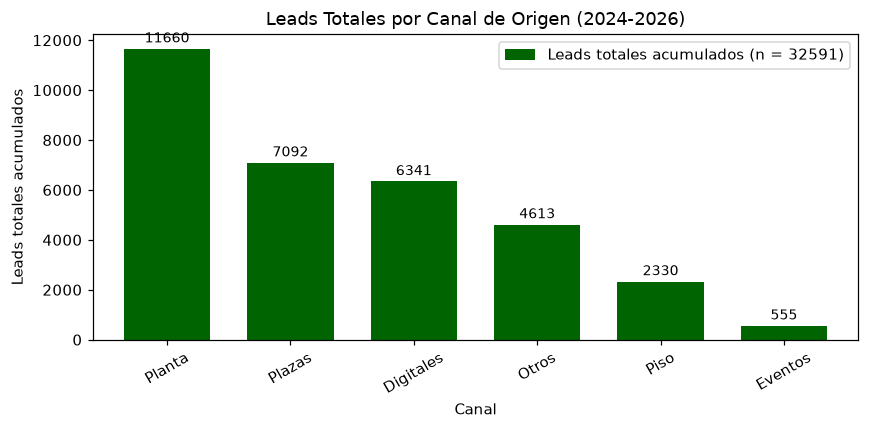

In [29]:
Tabla_freq = leads_canal.groupby('Canal')['Leads'].sum().reset_index()
Tabla_freq.columns = ['Canal', 'count']
Filtro_index = Tabla_freq.sort_values('count', ascending=False).set_index('Canal')
n_total = int(Filtro_index['count'].sum())
Filtro_index.columns = [f'Leads totales acumulados (n = {n_total})']

ax = Filtro_index.plot(kind='bar', width=0.7, color='darkgreen', figsize=(8,4), legend=True, rot=30)
plt.title(f'Leads Totales por Canal de Origen (2024-2026)')
plt.xlabel('Canal'); plt.ylabel('Leads totales acumulados')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

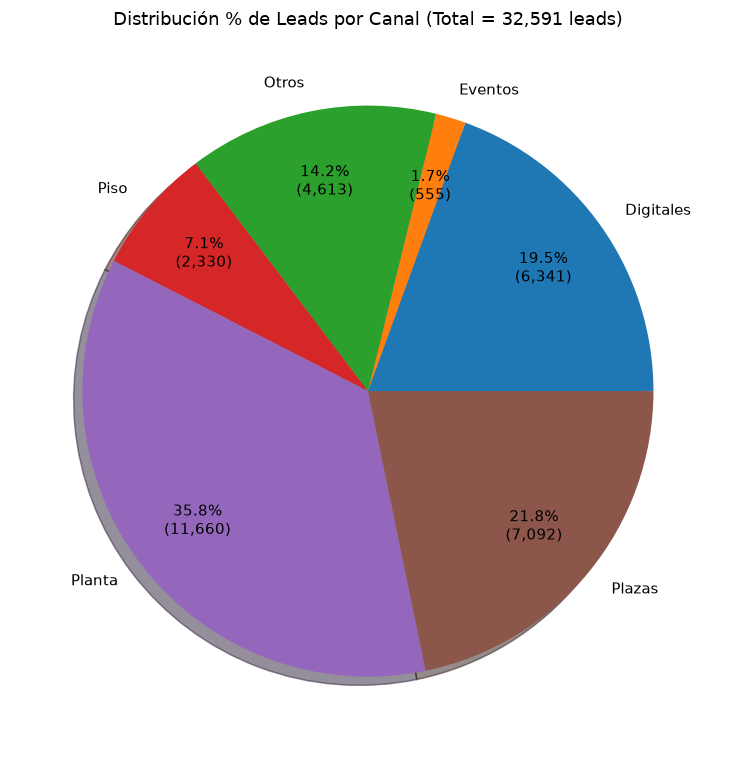

In [22]:
def autopct_con_valor(valores):
    def inner(pct):
        val = int(round(pct/100.*sum(valores)))
        return f'{pct:.1f}%\n({val:,})'
    return inner

Tabla_freq2 = Tabla_freq.sort_values('Canal')
total_leads = int(Tabla_freq2['count'].sum())

fig, ax = plt.subplots(figsize=(7.5,7))
ax.pie(Tabla_freq2['count'], labels=Tabla_freq2['Canal'], autopct=autopct_con_valor(Tabla_freq2['count']),
       shadow=True, pctdistance=0.75)
ax.set_title(f'Distribución % de Leads por Canal (Total = {total_leads:,} leads)')
plt.tight_layout(); plt.show()

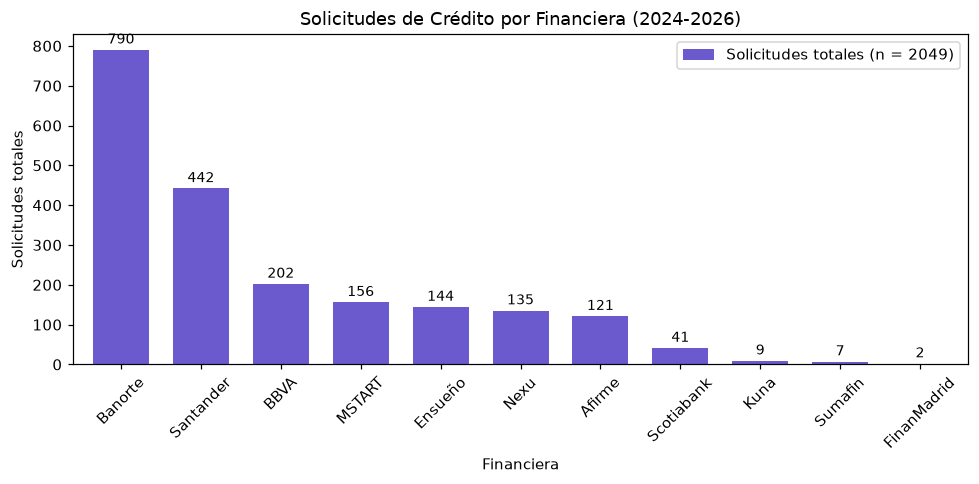

In [30]:
Filtro = financieras[financieras['Total'] > 1].sort_values('Total', ascending=False)
Filtro_index = Filtro.set_index('Financiera')
n_total = int(Filtro_index['Total'].sum())
Filtro_index.columns = [f'Solicitudes totales (n = {n_total})']

ax = Filtro_index.plot(kind='bar', width=0.7, color='slateblue', figsize=(9,4.5), legend=True, rot=45)
plt.title(f'Solicitudes de Crédito por Financiera (2024-2026)')
plt.xlabel('Financiera'); plt.ylabel('Solicitudes totales')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

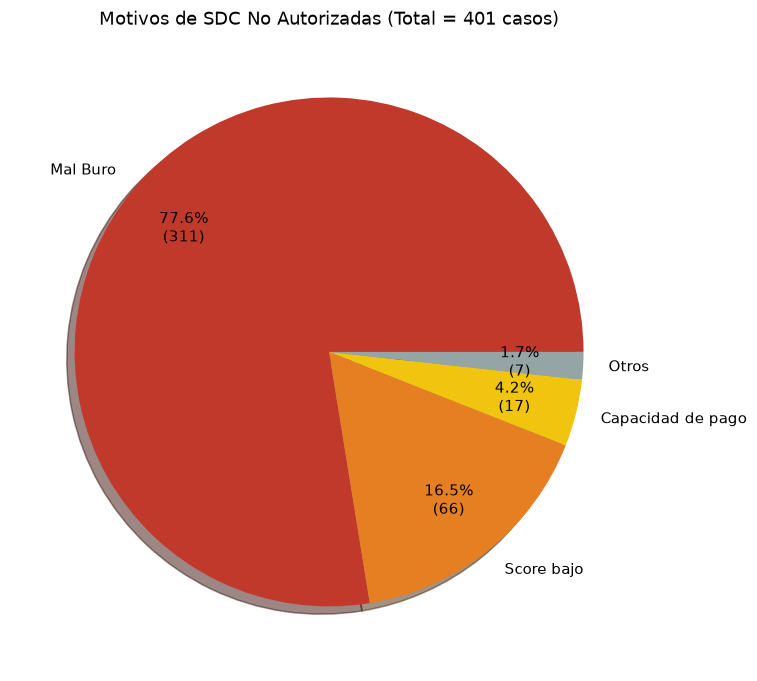

In [24]:
total_na = int(no_autorizadas['Total'].sum())
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(no_autorizadas['Total'], labels=no_autorizadas['Motivo'],
       autopct=autopct_con_valor(no_autorizadas['Total']), shadow=True, pctdistance=0.75,
       colors=['#c0392b','#e67e22','#f1c40f','#95a5a6'])
ax.set_title(f'Motivos de SDC No Autorizadas (Total = {total_na:,} casos)')
plt.tight_layout(); plt.show()

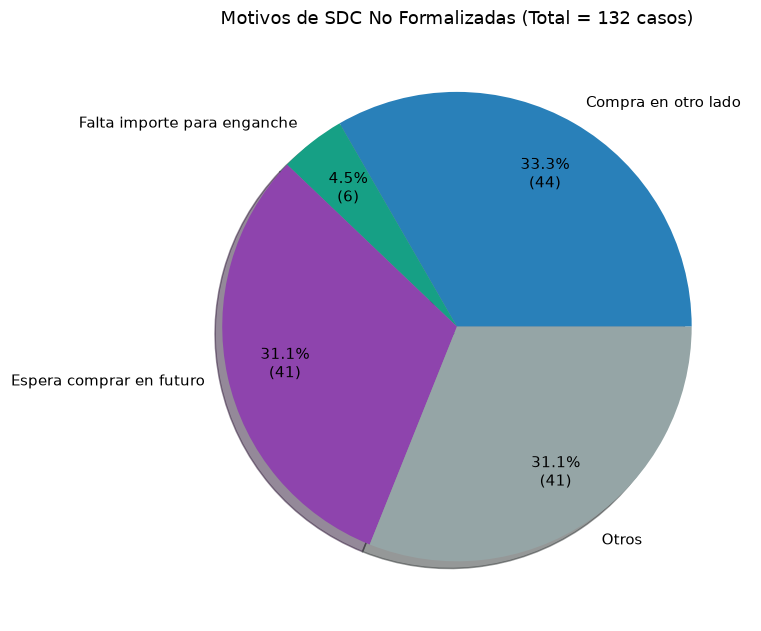

In [25]:
total_nf = int(no_formalizadas['Total'].sum())
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(no_formalizadas['Total'], labels=no_formalizadas['Motivo'],
       autopct=autopct_con_valor(no_formalizadas['Total']), shadow=True, pctdistance=0.75,
       colors=['#2980b9','#16a085','#8e44ad','#95a5a6'])
ax.set_title(f'Motivos de SDC No Formalizadas (Total = {total_nf:,} casos)')
plt.tight_layout(); plt.show()

Variables numéricas

n=31, Max=64, Min=20, R=44, ni=6


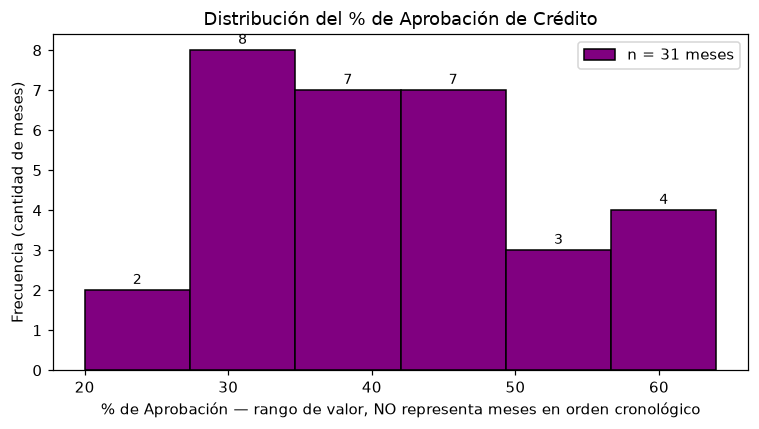

Periodo  Pct_Aprobacion Pct_Aprobacion_clase
 Jan-24              20     (19.956, 27.333]
 Aug-25              27     (19.956, 27.333]
 Dec-25              28     (27.333, 34.667]
 Jun-24              30     (27.333, 34.667]
 May-24              31     (27.333, 34.667]
 Jan-26              33     (27.333, 34.667]
 Nov-24              33     (27.333, 34.667]
 Feb-24              33     (27.333, 34.667]
 Sep-25              34     (27.333, 34.667]
 Mar-25              34     (27.333, 34.667]
 Feb-25              36       (34.667, 42.0]
 Jan-25              36       (34.667, 42.0]
 Dec-24              38       (34.667, 42.0]
 Jul-26              38       (34.667, 42.0]
 Oct-25              38       (34.667, 42.0]
 Oct-24              39       (34.667, 42.0]
 Jul-25              39       (34.667, 42.0]
 Nov-25              42       (34.667, 42.0]
 Jun-26              43       (42.0, 49.333]
 Feb-26              45       (42.0, 49.333]
 May-26              46       (42.0, 49.333]
 Sep-24   

In [31]:
col = 'Pct_Aprobacion'
n = sdc[col].count()
Max = sdc[col].max(); Min = sdc[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
print(f"n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}")

fig, ax = plt.subplots(figsize=(7,4))
counts, bins, patches = ax.hist(sdc[col], bins=ni, color='purple', edgecolor='black', label=f'n = {n} meses')
ax.bar_label(patches, labels=[int(c) for c in counts], padding=2, fontsize=9)
ax.set_title(f'Distribución del % de Aprobación de Crédito')
ax.set_xlabel('% de Aprobación — rango de valor, NO representa meses en orden cronológico')
ax.set_ylabel('Frecuencia (cantidad de meses)')
ax.legend()
plt.tight_layout(); plt.show()

# Tabla de referencia: qué mes cae en cada rango
sdc['Pct_Aprobacion_clase'] = pd.cut(sdc['Pct_Aprobacion'], bins=ni)
print(sdc[['Periodo','Pct_Aprobacion','Pct_Aprobacion_clase']].sort_values('Pct_Aprobacion').to_string(index=False))

n=31, Max=25, Min=1, R=24, ni=6, i=4.0


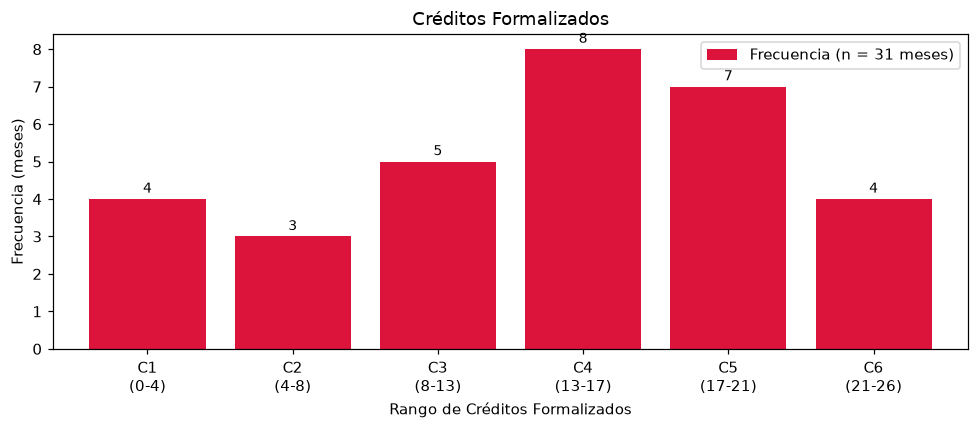

Periodo  Formalizadas Formalizadas_clase
 Jan-24             1          C1\n(0-4)
 Feb-24             1          C1\n(0-4)
 May-24             3          C1\n(0-4)
 Jul-26             4          C1\n(0-4)
 Mar-24             5          C2\n(4-8)
 Jun-24             6          C2\n(4-8)
 Sep-24             7          C2\n(4-8)
 Aug-24             9         C3\n(8-13)
 Apr-24            11         C3\n(8-13)
 Feb-25            12         C3\n(8-13)
 Aug-25            13         C3\n(8-13)
 Jun-26            13         C3\n(8-13)
 Dec-25            14        C4\n(13-17)
 Nov-24            14        C4\n(13-17)
 Oct-24            14        C4\n(13-17)
 Apr-26            16        C4\n(13-17)
 Jul-24            17        C4\n(13-17)
 Feb-26            17        C4\n(13-17)
 Apr-25            17        C4\n(13-17)
 Dec-24            17        C4\n(13-17)
 Mar-26            18        C5\n(17-21)
 Jan-25            19        C5\n(17-21)
 May-26            19        C5\n(17-21)
 May-25         

In [34]:
col = 'Formalizadas'
n = sdc[col].count()
Max = sdc[col].max(); Min = sdc[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-1, Max+1, ni+1)
categorias = [f"C{k+1}\n({int(intervalos[k])}-{int(intervalos[k+1])})" for k in range(ni)]
sdc[f'{col}_clase'] = pd.cut(sdc[col], bins=intervalos, labels=categorias)

Tabla_freq = sdc[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='crimson', figsize=(9,4), legend=True, rot=0)
plt.title(f'Créditos Formalizados')
plt.xlabel('Rango de Créditos Formalizados'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

# Tabla de referencia
print(sdc[['Periodo', col, f'{col}_clase']].sort_values(col).to_string(index=False))

n=13, Max=349.47, Min=116.16, R=233.31000000000003, ni=5, i=46.66


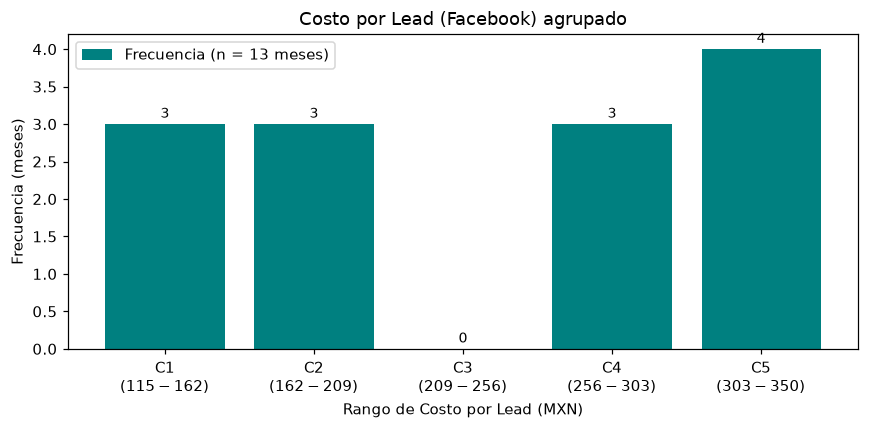

       Periodo  Costo_por_Lead Costo_por_Lead_clase
     Abril, 25          116.16      C1\n($115-$162)
     Julio, 25          142.61      C1\n($115-$162)
     Junio, 25          150.69      C1\n($115-$162)
    Agosto, 25          167.43      C2\n($162-$209)
      Mayo, 25          180.27      C2\n($162-$209)
   Octubre, 25          180.38      C2\n($162-$209)
        Apr-26          261.56      C4\n($256-$303)
Septiembre, 25          263.43      C4\n($256-$303)
        Mar-26          269.41      C4\n($256-$303)
   Febrero, 26          304.33      C5\n($303-$350)
 Noviembre, 25          327.01      C5\n($303-$350)
     Enero, 26          337.14      C5\n($303-$350)
 Diciembre, 25          349.47      C5\n($303-$350)


In [35]:
col = 'Costo_por_Lead'
n = cpl[col].count()
Max = cpl[col].max(); Min = cpl[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-1, Max+1, ni+1)
categorias = [f"C{k+1}\n(${int(intervalos[k])}-${int(intervalos[k+1])})" for k in range(ni)]
cpl[f'{col}_clase'] = pd.cut(cpl[col], bins=intervalos, labels=categorias)

Tabla_freq = cpl[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='teal', figsize=(8,4), legend=True, rot=0)
plt.title(f'Costo por Lead (Facebook) agrupado')
plt.xlabel('Rango de Costo por Lead (MXN)'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

# Tabla de referencia
print(cpl[['Periodo', col, f'{col}_clase']].sort_values(col).to_string(index=False))